
Loaded file: D:\edge下载\titanic.csv

[Titanic] Before preprocessing
Shape: (891, 15)
Missing cells: 869
Duplicate rows: 107
Dtypes summary:
object     7
int64      4
float64    2
bool       2
Name: count, dtype: int64


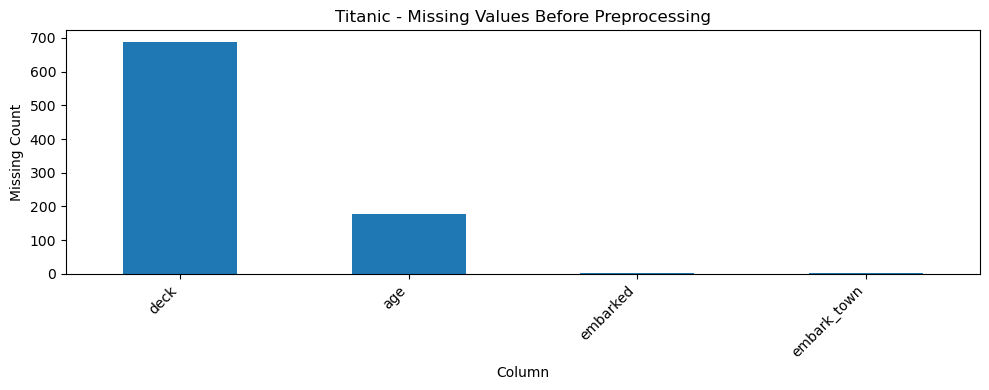

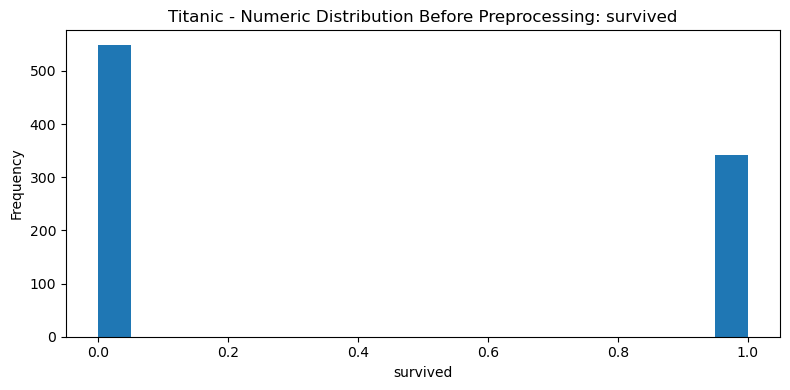

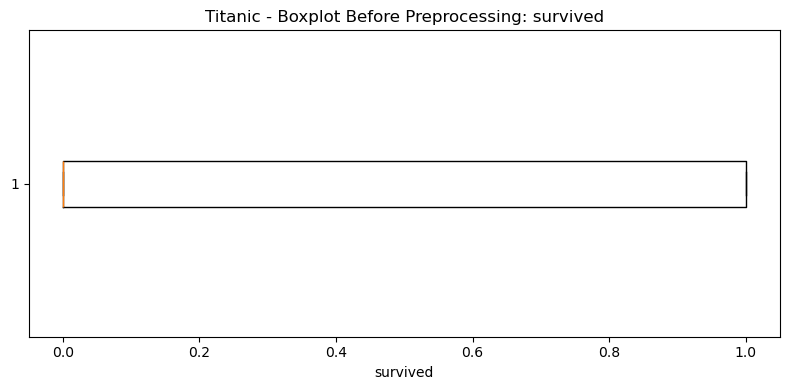

Step 1 done: standardized missing-value tokens.
Step 2 done: handled missing values.
Step 3 done: removed 112 duplicate rows.
Step 4 done: standardized formats.
Step 5 skipped: scaling not applied.
Step 6 skipped: encoding not applied.
Step 7 skipped: outlier handling not applied.

[Titanic] After preprocessing
Shape: (779, 15)
Missing cells: 0
Duplicate rows: 0
Dtypes summary:
object     7
int64      4
float64    2
bool       2
Name: count, dtype: int64


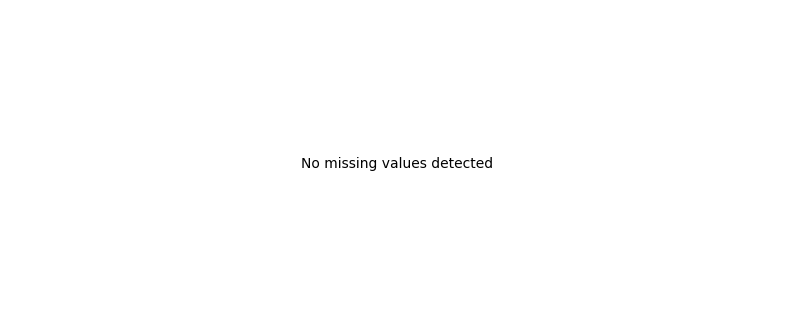

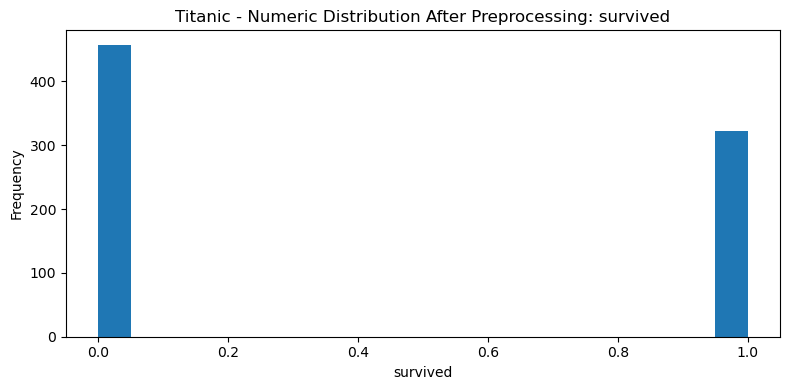

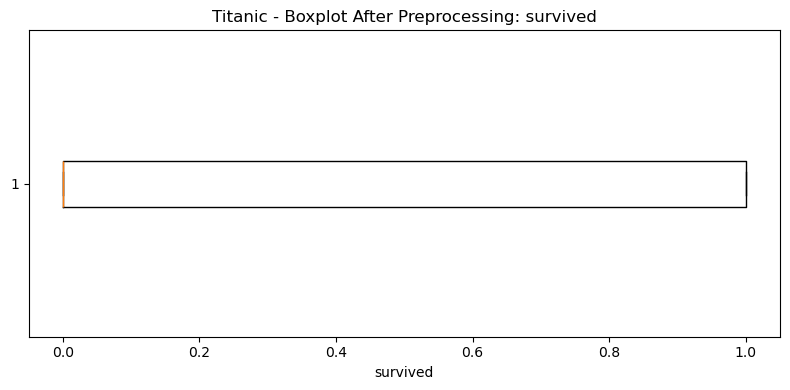

Saved cleaned data to: D:\edge下载\titanic_cleaned.csv

Loaded file: D:\edge下载\ames_housing.csv

[Ames Housing] Before preprocessing
Shape: (1460, 81)
Missing cells: 7829
Duplicate rows: 0
Dtypes summary:
object     43
int64      35
float64     3
Name: count, dtype: int64


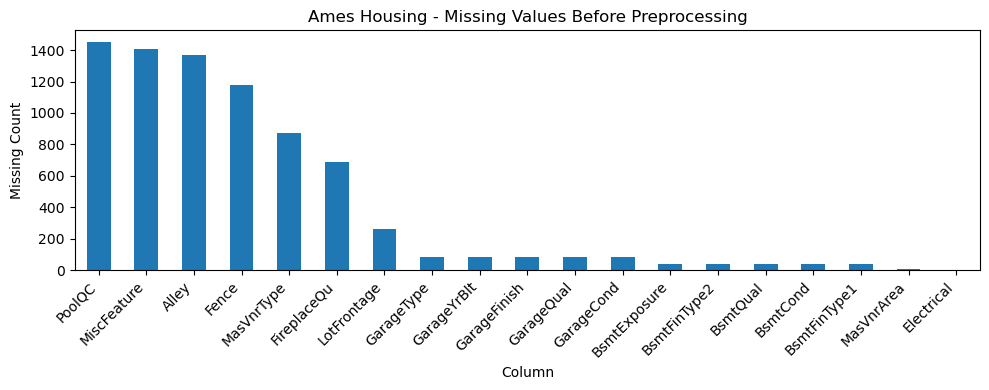

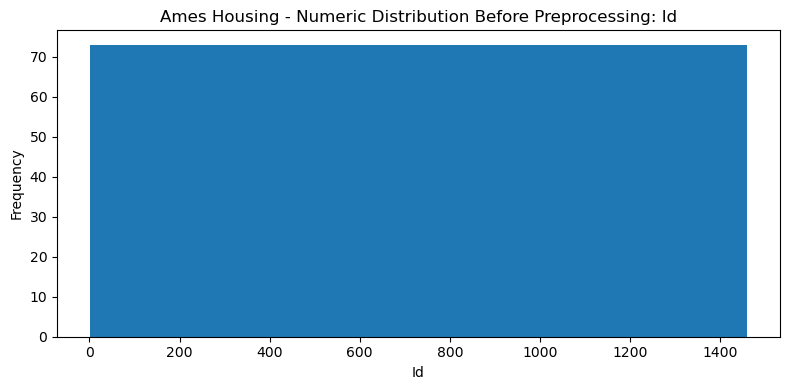

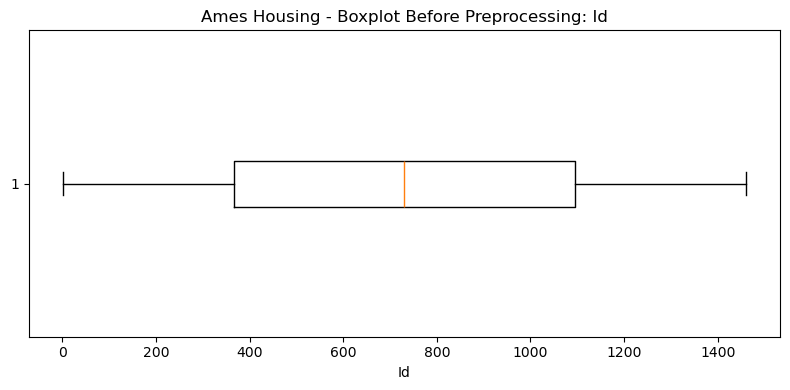

Step 1 done: standardized missing-value tokens.
Step 2 done: handled missing values.
Step 3 done: removed 0 duplicate rows.
Step 4 done: standardized formats.
Step 5 skipped: scaling not applied.
Step 6 skipped: encoding not applied.
Step 7 skipped: outlier handling not applied.

[Ames Housing] After preprocessing
Shape: (1460, 81)
Missing cells: 0
Duplicate rows: 0
Dtypes summary:
object     43
int64      35
float64     3
Name: count, dtype: int64


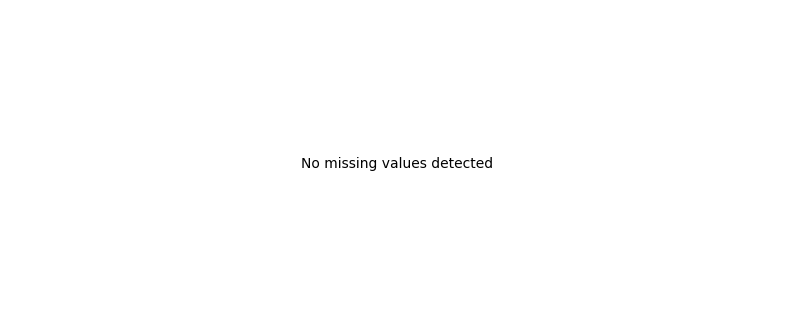

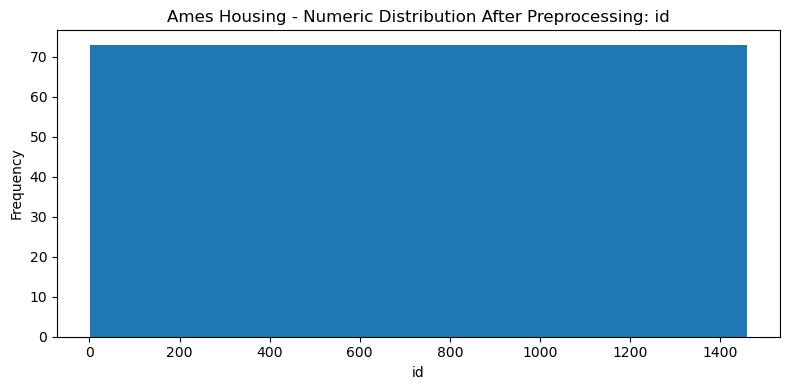

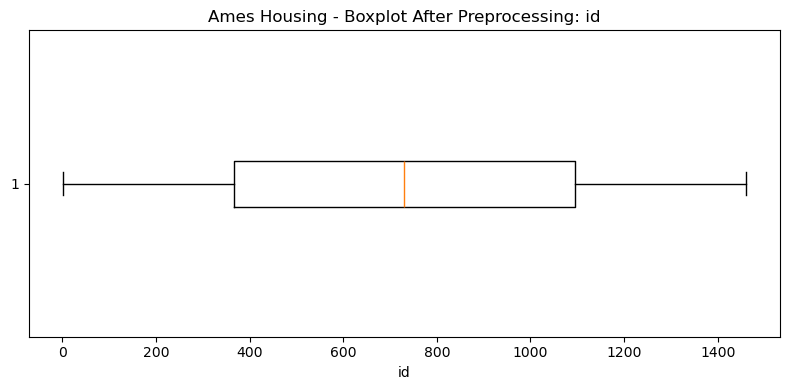

Saved cleaned data to: D:\edge下载\ames_housing_cleaned.csv

Titanic cleaned preview:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True    C  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False    C  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True    C  Southampton    no   True  

Ames Housing cleaned preview:
   id  mssubclass mszoning  lotfrontage  lotarea street alley lotshape  \
0   1          60       RL    

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler


def preprocess_data(
    file_path,
    output_path=None,
    missing_tokens=None,
    strip_text_before_missing=True,
    missing_strategy="impute_mean_median_mode",
    missing_threshold=0.5,
    numeric_impute="median",
    categorical_impute="mode",
    remove_duplicates=True,
    standardize_colnames=True,
    trim_text=True,
    lowercase_text=False,
    try_numeric_conversion=True,
    scaling_method="none",   # "none", "standard", "minmax"
    encoding_method="none",  # "none", "onehot", "label"
    outlier_method="none",   # "none", "iqr_remove", "iqr_cap"
    show_plots=True,
    dataset_name="dataset"
):
    """
    End-to-end data preprocessing function with basic visualization.
    """

    # ================================================================
    # Helper functions
    # ================================================================
    def get_numeric_cols(dataframe):
        return dataframe.select_dtypes(include="number").columns.tolist()

    def get_categorical_cols(dataframe):
        return dataframe.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    def standardize_col_name(name):
        name = str(name).strip().lower()
        name = re.sub(r"\s+", "_", name)
        name = re.sub(r"[^a-z0-9_]", "", name)
        name = re.sub(r"_+", "_", name)
        return name.strip("_")

    def plot_missing_values(dataframe, title):
        missing_counts = dataframe.isna().sum()
        missing_counts = missing_counts[missing_counts > 0]

        plt.figure(figsize=(10, 4))
        if missing_counts.empty:
            plt.text(0.5, 0.5, "No missing values detected", ha="center", va="center")
            plt.axis("off")
        else:
            missing_counts.sort_values(ascending=False).plot(kind="bar")
            plt.title(title)
            plt.xlabel("Column")
            plt.ylabel("Missing Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
        plt.show()

    def plot_histogram(dataframe, title):
        numeric_cols = get_numeric_cols(dataframe)

        plt.figure(figsize=(8, 4))
        if not numeric_cols:
            plt.text(0.5, 0.5, "No numeric columns available", ha="center", va="center")
            plt.axis("off")
            plt.title(title)
            plt.show()
            return

        col = numeric_cols[0]
        series = dataframe[col].dropna()

        if series.empty:
            plt.text(0.5, 0.5, "Selected numeric column has no valid values", ha="center", va="center")
            plt.axis("off")
            plt.title(title)
            plt.show()
            return

        plt.hist(series, bins=20)
        plt.title(f"{title}: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

    def plot_boxplot(dataframe, title):
        numeric_cols = get_numeric_cols(dataframe)

        plt.figure(figsize=(8, 4))
        if not numeric_cols:
            plt.text(0.5, 0.5, "No numeric columns available", ha="center", va="center")
            plt.axis("off")
            plt.title(title)
            plt.show()
            return

        col = numeric_cols[0]
        series = dataframe[col].dropna()

        if series.empty:
            plt.text(0.5, 0.5, "Selected numeric column has no valid values", ha="center", va="center")
            plt.axis("off")
            plt.title(title)
            plt.show()
            return

        plt.boxplot(series, vert=False)
        plt.title(f"{title}: {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

    def show_summary(dataframe, stage_name):
        print(f"\n[{dataset_name}] {stage_name}")
        print(f"Shape: {dataframe.shape}")
        print(f"Missing cells: {int(dataframe.isna().sum().sum())}")
        print(f"Duplicate rows: {int(dataframe.duplicated().sum())}")
        print("Dtypes summary:")
        print(dataframe.dtypes.value_counts())

    # ================================================================
    # Step 0: Read data
    # ================================================================
    df = pd.read_csv(file_path)
    print(f"\nLoaded file: {file_path}")

    if missing_tokens is None:
        missing_tokens = ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "?", "-"]

    # ================================================================
    # Visualization before preprocessing
    # ================================================================
    show_summary(df, "Before preprocessing")
    if show_plots:
        plot_missing_values(df, f"{dataset_name} - Missing Values Before Preprocessing")
        plot_histogram(df, f"{dataset_name} - Numeric Distribution Before Preprocessing")
        plot_boxplot(df, f"{dataset_name} - Boxplot Before Preprocessing")

    # ================================================================
    # Step 1: Standardize missing-value representation
    # ================================================================
    for col in df.columns:
        if df[col].dtype == "object" or str(df[col].dtype) == "category":
            df[col] = df[col].astype("object")

            if strip_text_before_missing:
                df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

            df[col] = df[col].replace(missing_tokens, pd.NA)

    print("Step 1 done: standardized missing-value tokens.")

    # ================================================================
    # Step 2: Handle missing values
    # ================================================================
    if missing_strategy == "drop_rows":
        df = df.dropna().reset_index(drop=True)

    elif missing_strategy == "drop_cols_threshold":
        missing_ratio = df.isna().mean()
        cols_to_keep = missing_ratio[missing_ratio <= missing_threshold].index.tolist()
        df = df[cols_to_keep].copy()

    elif missing_strategy == "impute_mean_median_mode":
        numeric_cols = get_numeric_cols(df)
        categorical_cols = get_categorical_cols(df)

        for col in numeric_cols:
            if df[col].isna().any():
                if numeric_impute == "mean":
                    fill_value = df[col].mean()
                else:
                    fill_value = df[col].median()
                df[col] = df[col].fillna(fill_value)

        for col in categorical_cols:
            if df[col].isna().any():
                if categorical_impute == "mode":
                    mode_series = df[col].mode(dropna=True)
                    fill_value = mode_series.iloc[0] if not mode_series.empty else "Unknown"
                else:
                    fill_value = "Unknown"
                df[col] = df[col].fillna(fill_value)

    print("Step 2 done: handled missing values.")

    # ================================================================
    # Step 3: Remove duplicates
    # ================================================================
    if remove_duplicates:
        before_rows = len(df)
        df = df.drop_duplicates().reset_index(drop=True)
        after_rows = len(df)
        print(f"Step 3 done: removed {before_rows - after_rows} duplicate rows.")
    else:
        print("Step 3 skipped: duplicate removal not applied.")

    # ================================================================
    # Step 4: Format standardization
    # ================================================================
    if standardize_colnames:
        df.columns = [standardize_col_name(col) for col in df.columns]

    text_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in text_cols:
        df[col] = df[col].astype("object")

        if trim_text:
            df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

        if lowercase_text:
            df[col] = df[col].apply(lambda x: x.lower() if isinstance(x, str) else x)

    if try_numeric_conversion:
        object_cols = df.select_dtypes(include=["object"]).columns.tolist()
        for col in object_cols:
            converted = pd.to_numeric(df[col], errors="coerce")

            non_missing_original = df[col].notna().sum()
            non_missing_converted = converted.notna().sum()

            if non_missing_original > 0 and non_missing_converted > 0:
                if non_missing_original == non_missing_converted:
                    df[col] = converted

    print("Step 4 done: standardized formats.")

    # ================================================================
    # Step 5: Scale numeric features
    # ================================================================
    if scaling_method != "none":
        numeric_cols = get_numeric_cols(df)
        cols_to_scale = [col for col in numeric_cols if not df[col].isna().any()]

        if cols_to_scale:
            if scaling_method == "standard":
                scaler = StandardScaler()
            else:
                scaler = MinMaxScaler()

            df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
            print(f"Step 5 done: applied {scaling_method} scaling.")
        else:
            print("Step 5 skipped: no numeric columns available for scaling.")
    else:
        print("Step 5 skipped: scaling not applied.")

    # ================================================================
    # Step 6: Encode categorical features
    # ================================================================
    if encoding_method != "none":
        cat_cols = get_categorical_cols(df)

        if cat_cols:
            if encoding_method == "onehot":
                df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
            elif encoding_method == "label":
                for col in cat_cols:
                    df[col] = df[col].astype("category").cat.codes

            print(f"Step 6 done: applied {encoding_method} encoding.")
        else:
            print("Step 6 skipped: no categorical columns available for encoding.")
    else:
        print("Step 6 skipped: encoding not applied.")

    # ================================================================
    # Step 7: Handle outliers
    # ================================================================
    if outlier_method != "none":
        numeric_cols = get_numeric_cols(df)

        if outlier_method == "iqr_remove":
            keep_mask = pd.Series([True] * len(df), index=df.index)

            for col in numeric_cols:
                series = df[col].dropna()
                if series.empty:
                    continue

                q1 = series.quantile(0.25)
                q3 = series.quantile(0.75)
                iqr = q3 - q1

                if iqr == 0:
                    continue

                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr

                col_mask = df[col].isna() | ((df[col] >= lower) & (df[col] <= upper))
                keep_mask = keep_mask & col_mask

            before_rows = len(df)
            df = df.loc[keep_mask].reset_index(drop=True)
            after_rows = len(df)
            print(f"Step 7 done: removed {before_rows - after_rows} rows by IQR outlier rule.")

        elif outlier_method == "iqr_cap":
            for col in numeric_cols:
                series = df[col].dropna()
                if series.empty:
                    continue

                q1 = series.quantile(0.25)
                q3 = series.quantile(0.75)
                iqr = q3 - q1

                if iqr == 0:
                    continue

                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr

                df[col] = df[col].clip(lower=lower, upper=upper)

            print("Step 7 done: capped outliers by IQR rule.")
    else:
        print("Step 7 skipped: outlier handling not applied.")

    # ================================================================
    # Visualization after preprocessing
    # ================================================================
    show_summary(df, "After preprocessing")
    if show_plots:
        plot_missing_values(df, f"{dataset_name} - Missing Values After Preprocessing")
        plot_histogram(df, f"{dataset_name} - Numeric Distribution After Preprocessing")
        plot_boxplot(df, f"{dataset_name} - Boxplot After Preprocessing")

    # Save file if needed
    if output_path is not None:
        df.to_csv(output_path, index=False)
        print(f"Saved cleaned data to: {output_path}")

    return df


if __name__ == "__main__":
    titanic_path = r"D:\edge下载\titanic.csv"
    ames_path = r"D:\edge下载\ames_housing.csv"

    titanic_cleaned = preprocess_data(
        file_path=titanic_path,
        output_path=r"D:\edge下载\titanic_cleaned.csv",
        missing_strategy="impute_mean_median_mode",
        numeric_impute="median",
        categorical_impute="mode",
        remove_duplicates=True,
        standardize_colnames=True,
        trim_text=True,
        lowercase_text=False,
        try_numeric_conversion=True,
        scaling_method="none",
        encoding_method="none",
        outlier_method="none",
        show_plots=True,
        dataset_name="Titanic"
    )

    ames_cleaned = preprocess_data(
        file_path=ames_path,
        output_path=r"D:\edge下载\ames_housing_cleaned.csv",
        missing_strategy="impute_mean_median_mode",
        numeric_impute="median",
        categorical_impute="mode",
        remove_duplicates=True,
        standardize_colnames=True,
        trim_text=True,
        lowercase_text=False,
        try_numeric_conversion=True,
        scaling_method="none",
        encoding_method="none",
        outlier_method="none",
        show_plots=True,
        dataset_name="Ames Housing"
    )

    print("\nTitanic cleaned preview:")
    print(titanic_cleaned.head())

    print("\nAmes Housing cleaned preview:")
    print(ames_cleaned.head())